<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Regression/ols_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SuccessRate i = proportion of climbers who summited in expedition / year / route 𝑖

General Regression Equation:


SuccessRatei​=β0​+β1​Yeari​+β2​Seasoni​+β3​Citizenshipi​+β4​Routei​+β5​SupportRatioi​+β6​Crowdingi​+β7​Exped

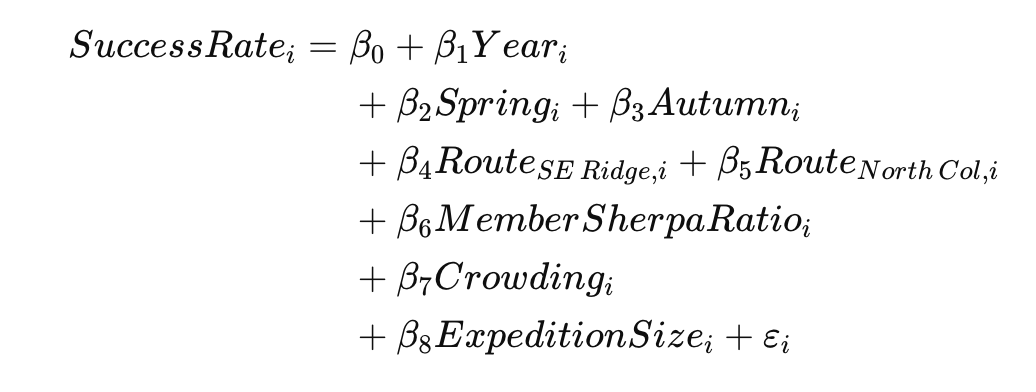

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pylab
import pandas as pd
import numpy as np

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.2)
sns.set_style("white")

Mounted at /content/drive


In [2]:
df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions5.csv")

In [3]:
# --- 1) Keep only what we need for regression ---
keep = [
    "ExpedID",
    "Yr/Seas",
    "Year",
    "Nationalities",     # proxy for citizenship
    "route_codes",       # route category
    "mbr_hired_ratio",   # sherpa/member style support
    "group_size",        # expedition size
    "success_rate"       # dependent variable
]

df1 = df[keep].copy()

# --- 2) Create year-level crowding variable ---
# Total number of climbers per year (system-level crowding)
df1["yearly_members"] = (
    df1
    .groupby("Year")["group_size"]
    .transform("sum")
)

df1.head(30)


,ExpedID,Yr/Seas,Year,Nationalities,route_codes,mbr_hired_ratio,group_size,success_rate,yearly_members
0,EVER-901-03,1990 Spr,1990,"USA, China, USSR",2,0.00,39.0,0.512820513,276.0
1,EVER-901-04,1990 Spr,1990,Nepal,1,0.08,28.0,0.142857143,276.0
2,EVER-901-06,1990 Spr,1990,Australia,6,0.00,4.0,0.25,276.0
3,EVER-901-07,1990 Spr,1990,USA,1,0.30,13.0,0.692307692,276.0
4,EVER-901-08,1990 Spr,1990,"New Zealand, Belgium, Canada, Sweden, USA",1,0.10,11.0,0.636363636,276.0
5,EVER-903-03,1990 Aut,1990,"S Korea, Japan",1,0.21,17.0,0.294117647,276.0
6,EVER-903-05,1990 Aut,1990,"France, Netherlands, Switzerland, USA",1,0.09,24.0,0.333333333,276.0
7,EVER-903-07,1990 Aut,1990,"USA, Canada, USSR",6,0.18,13.0,0.538461538,276.0
8,EVER-903-09,1990 Aut,1990,"France, Belgium",1,0.17,21.0,0.333333333,276.0
9,EVER-903-10,1990 Aut,1990,"Yugoslavia, Italy",6,0.14,16.0,0.25,276.0


In [4]:
# Extract season from Yr/Seas
df1["Season"] = (
    df1["Yr/Seas"]
    .astype(str)
    .str.extract(r"(Spr|Sum|Aut|Fal|Win)", expand=False)
)

# Map abbreviations to full names (optional but nicer for write-up)
season_map = {
    "Spr": "Spring",
    "Sum": "Summer",
    "Aut": "Autumn",
    "Fal": "Autumn",
    "Win": "Winter"
}

df1["Season"] = df1["Season"].map(season_map)

df1[["Yr/Seas", "Year", "Season"]].head()

,Yr/Seas,Year,Season
0,1990 Spr,1990,Spring
1,1990 Spr,1990,Spring
2,1990 Spr,1990,Spring
3,1990 Spr,1990,Spring
4,1990 Spr,1990,Spring


In [5]:
# Primary nationality = first listed nationality
df1["PrimaryNationality"] = (
    df1["Nationalities"]
    .astype(str)
    .str.split(",", n=1)
    .str[0]
    .str.strip()
)


In [6]:
df1["MultiNational"] = (
    df1["Nationalities"]
    .astype(str)
    .str.contains(",")
    .astype(int)
)

df1[["Nationalities", "PrimaryNationality", "MultiNational"]].head()


,Nationalities,PrimaryNationality,MultiNational
0,"USA, China, USSR",USA,1
1,Nepal,Nepal,0
2,Australia,Australia,0
3,USA,USA,0
4,"New Zealand, Belgium, Canada, Sweden, USA",New Zealand,1


In [7]:
df_clean = df1.drop(columns=["Nationalities", "Yr/Seas", "ExpedID"])
df_clean.head(20)


,Year,route_codes,mbr_hired_ratio,group_size,success_rate,yearly_members,Season,PrimaryNationality,MultiNational
0,1990,2,0.00,39.0,0.512820513,276.0,Spring,USA,1
1,1990,1,0.08,28.0,0.142857143,276.0,Spring,Nepal,0
2,1990,6,0.00,4.0,0.25,276.0,Spring,Australia,0
3,1990,1,0.30,13.0,0.692307692,276.0,Spring,USA,0
4,1990,1,0.10,11.0,0.636363636,276.0,Spring,New Zealand,1
5,1990,1,0.21,17.0,0.294117647,276.0,Autumn,S Korea,1
6,1990,1,0.09,24.0,0.333333333,276.0,Autumn,France,1
7,1990,6,0.18,13.0,0.538461538,276.0,Autumn,USA,1
8,1990,1,0.17,21.0,0.333333333,276.0,Autumn,France,1
9,1990,6,0.14,16.0,0.25,276.0,Autumn,Yugoslavia,1


In [8]:
# Save cleaned dataset to CSV
df_clean.to_csv("everest_regression_dataset.csv", index=False)

1. Summary Statistics Table of Summary Statistics

2. Visualisation Exploratory Plots

3. Assumptions A. Independence B. Heteroscedasticity: Regression plots + Q-Q plot C. Multicollinearity: VIF + Correlation Matrix

4. Regression Regression Table For the moment, when you run the regression, ignore the fact that we have panel data and just run a regular regression of the form

𝑌=𝛽0+𝛽1𝑋+𝜖

In [9]:
# 1. Summary Statistics (exclude dummy variables)
summary = (df_clean.drop(columns=["MultiNational", "Year", "route_codes"]).describe().round(2))

summary = summary.T
summary


,count,mean,std,min,25%,50%,75%,max
mbr_hired_ratio,2182.0,0.67,0.68,0.0,0.0,0.56,1.0,5.5
group_size,2190.0,10.59,10.87,1.0,3.0,7.00,14.0,79.0
yearly_members,2192.0,735.67,238.26,38.0,519.0,790.00,902.5,1136.0


Year, Season, Citizenship, Route codes are excluded from the summary statistics table, as their means and standard deviations are not informative in the same way as continuous variables. They are categorical

In [10]:
#Step 2: Visualisation

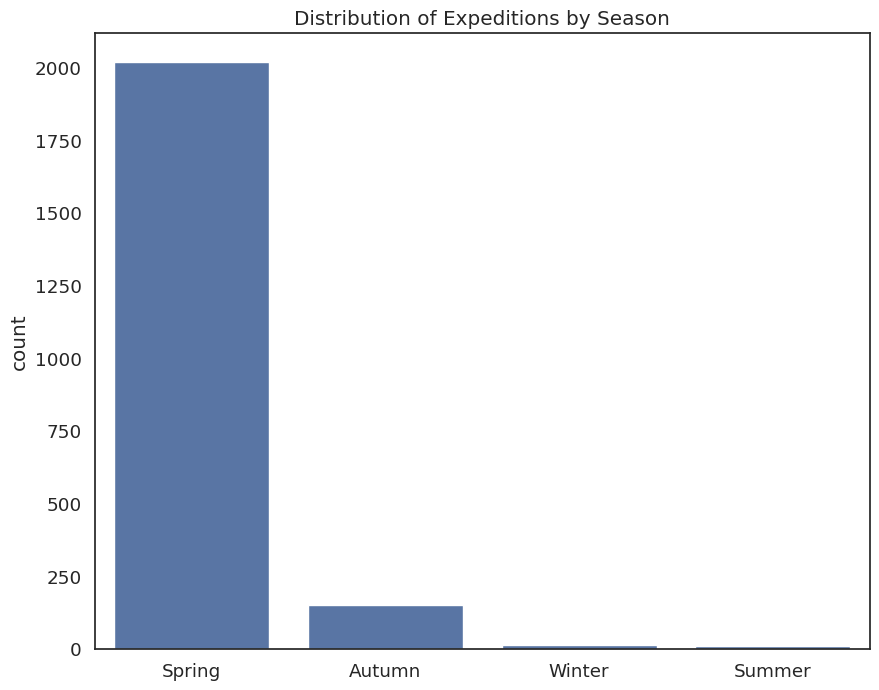

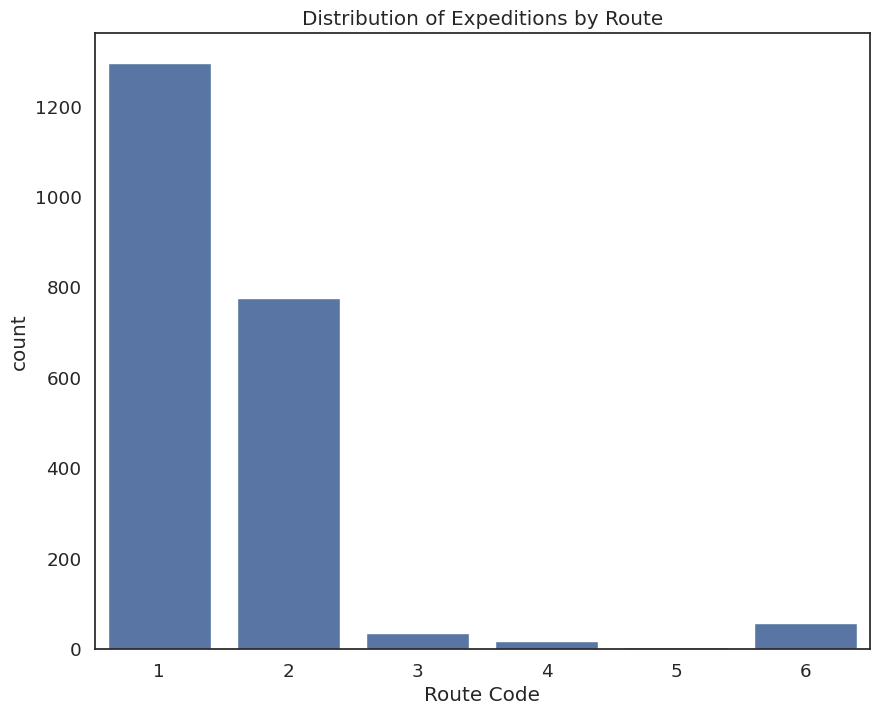

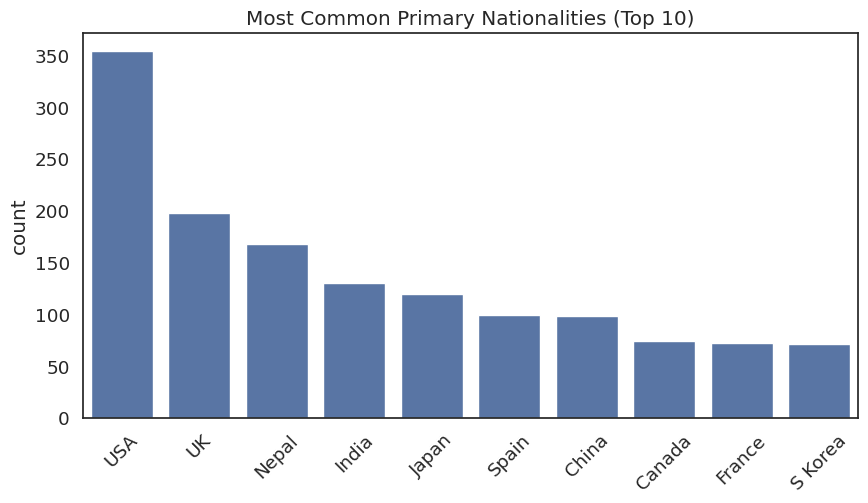

In [11]:
#A. Distribution of categorical variables (count plots)
import seaborn as sns
import matplotlib.pyplot as plt

#Season distribution
sns.countplot(data=df_clean, x="Season")
plt.title("Distribution of Expeditions by Season")
plt.xlabel("")
plt.show()

#Route distribution
sns.countplot(data=df_clean, x="route_codes")
plt.title("Distribution of Expeditions by Route")
plt.xlabel("Route Code")
plt.show()

#Nationality distribution (only Top 10)
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x="PrimaryNationality",
    order=df_clean["PrimaryNationality"].value_counts().index[:10]
)
plt.title("Most Common Primary Nationalities (Top 10)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.show()


1. Spring overwhelmingly dominates Everest expeditions. Autumn has far fewer expeditions. Winter and Summer are extremely rare. This means that most of our regression results will be driven by Spring data. Coefficients for Winter and Summer will be estimated from very small samples. Seasonal dummy coefficients (especially Winter/Summer) should be interpreted with caution.

2. Routes 1 and 2 dominate Everest expedition routes. Route 3, 4, 5 and 6 are used much less frequently. Popular routes likely benefit from better infrastructure, fixed ropes, and logistics. Less common routes may be riskier or more technical. Estimates for rare routes will have larger uncertainty.Differences may partly reflect selection effects (who chooses which route).

3. A small number of nationalities (USA, UK, Nepal, India) dominate expeditions. There is substantial diversity beyond the top few countries.Nationality captures systematic differences in expedition style, experience, and resources. But nationality is also a proxy, not a direct causal factor.

In [12]:
# Convert success_rate to numeric (anything weird becomes NaN)
df_clean["success_rate"] = pd.to_numeric(df_clean["success_rate"], errors="coerce")

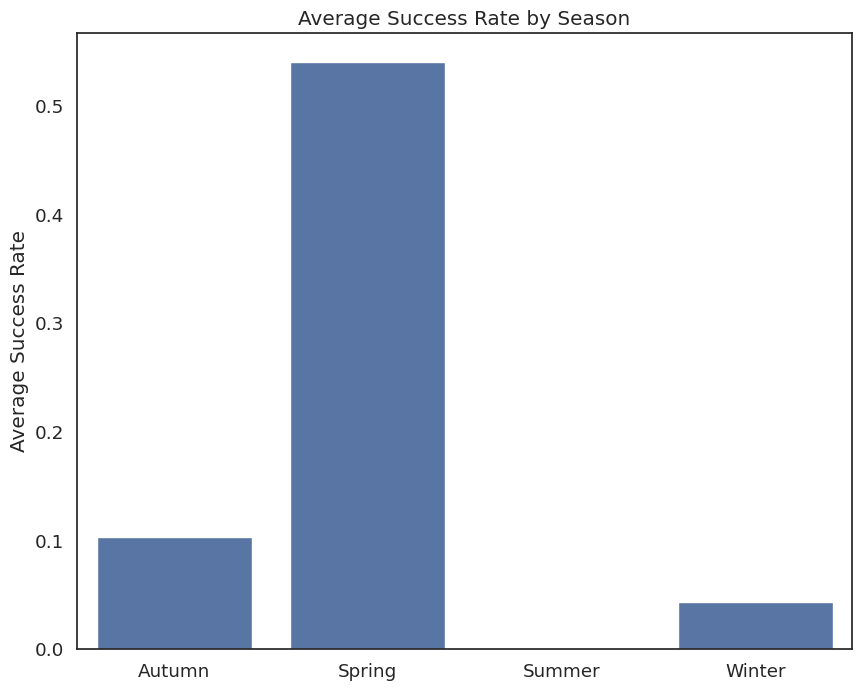

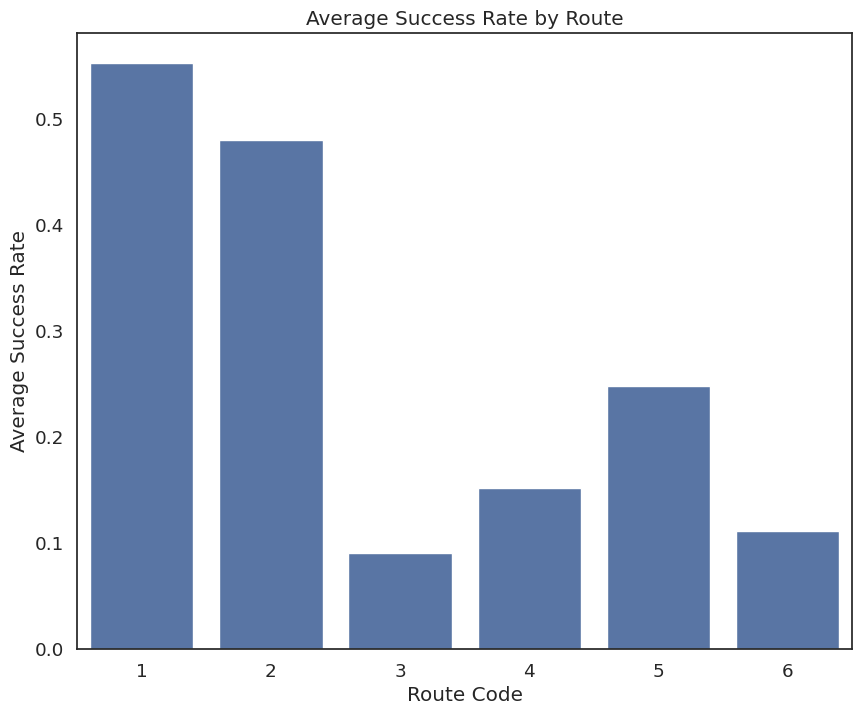

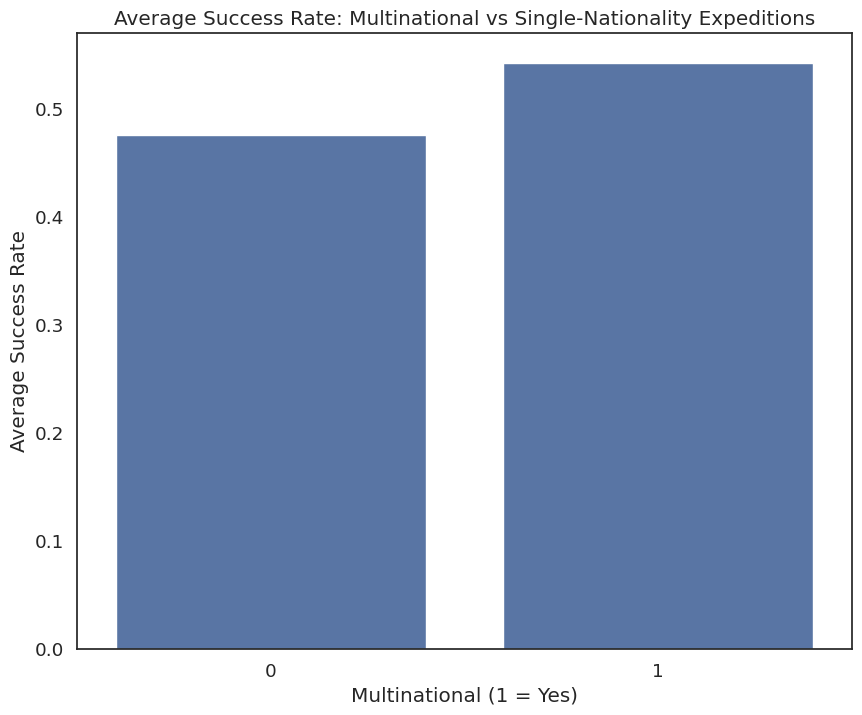

In [13]:
#B: Mean success rate by category - bar charts

season_mean = (
    df_clean
    .groupby("Season")["success_rate"]
    .mean()
    .reset_index()
)

sns.barplot(data=season_mean, x="Season", y="success_rate")
plt.title("Average Success Rate by Season")
plt.xlabel("")
plt.ylabel("Average Success Rate")
plt.show()

route_mean = (
    df_clean.groupby("route_codes", as_index=False)["success_rate"]
    .mean()
)

sns.barplot(data=route_mean, x="route_codes", y="success_rate")
plt.title("Average Success Rate by Route")
plt.xlabel("Route Code")
plt.ylabel("Average Success Rate")
plt.show()


multi_mean = (
    df_clean.groupby("MultiNational", as_index=False)["success_rate"]
    .mean()
)

sns.barplot(data=multi_mean, x="MultiNational", y="success_rate")
plt.title("Average Success Rate: Multinational vs Single-Nationality Expeditions")
plt.xlabel("Multinational (1 = Yes)")
plt.ylabel("Average Success Rate")
plt.show()



**Average Success Rate by Season**

Spring expeditions have by far the highest average success rate, while Autumn performs substantially worse and Winter and Summer success rates are close to zero. This indicates that favourable weather windows are a binding constraint on summit success. In the regression, we therefore expect non-Spring seasons to be associated with significantly lower success rates, and omitting season would likely bias other coefficients.

**Average Success Rate by Route**

Success rates differ markedly across routes, with Routes 1 and 2 achieving the highest average success. Less common and more technical routes perform worse on average, reflecting differences in difficulty and logistical support. Route controls in the regression help isolate route-specific risk, and other coefficients should be interpreted conditional on route choice.


**Average Success Rate by Expedition National Composition**

Multinational expeditions display higher average success rates than single-nationality expeditions. This may reflect stronger resource pooling, experience, or organisational support. A positive coefficient on the multinational indicator would be consistent with this pattern, though it may also capture unobserved expedition quality.

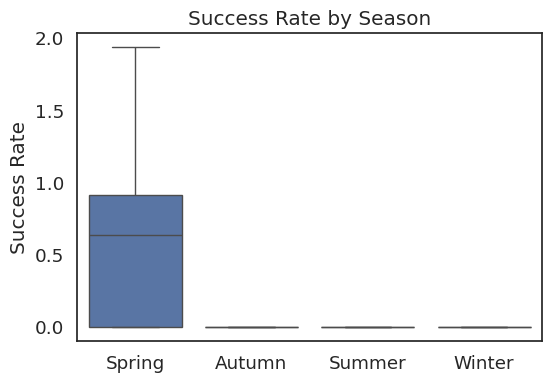

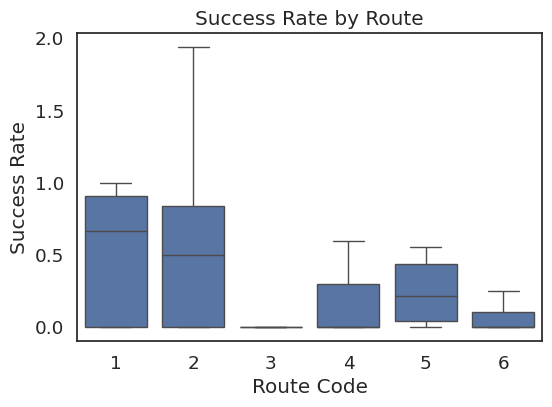

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_clean,
    x="Season",
    y="success_rate",
    showfliers=False,
    order=["Spring", "Autumn", "Summer", "Winter"]
)
plt.title("Success Rate by Season")
plt.xlabel("")
plt.ylabel("Success Rate")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_clean,
    x="route_codes",
    y="success_rate",
    showfliers=False
)
plt.title("Success Rate by Route")
plt.xlabel("Route Code")
plt.ylabel("Success Rate")
plt.show()


**Success Rate by Season (boxplot).**

The boxplot shows that Spring expeditions have a substantially higher median success rate and a much wider distribution than other seasons. In contrast, Autumn, Summer, and Winter exhibit success rates concentrated close to zero, with little variation. This reinforces the view that Spring provides uniquely favourable conditions for summit attempts, while success outside the main season is rare. In regression, this supports the inclusion of seasonal dummy variables and suggests large negative coefficients for non-Spring seasons relative to Spring.

**Success Rate by Route (boxplot).**

The boxplot indicates substantial heterogeneity in success rates across routes. Routes 1 and 2 display higher medians and wider dispersion, while less common routes show lower and more compressed success distributions. This pattern suggests that route choice materially affects summit outcomes, likely reflecting differences in technical difficulty and logistical support. In the regression, route dummies capture this route-specific risk, and other coefficients should be interpreted conditional on the chosen route.

In [15]:
#Step 3: Assumptions

**Independence**

Each expedition observed should be independent of the others, so that one expedition's outcome does not affect another.

Expeditions are indexed by year, season, and route, and there may be dependence within the same year or climbing season (e.g. shared weather windows, policy constraints, or crowding).

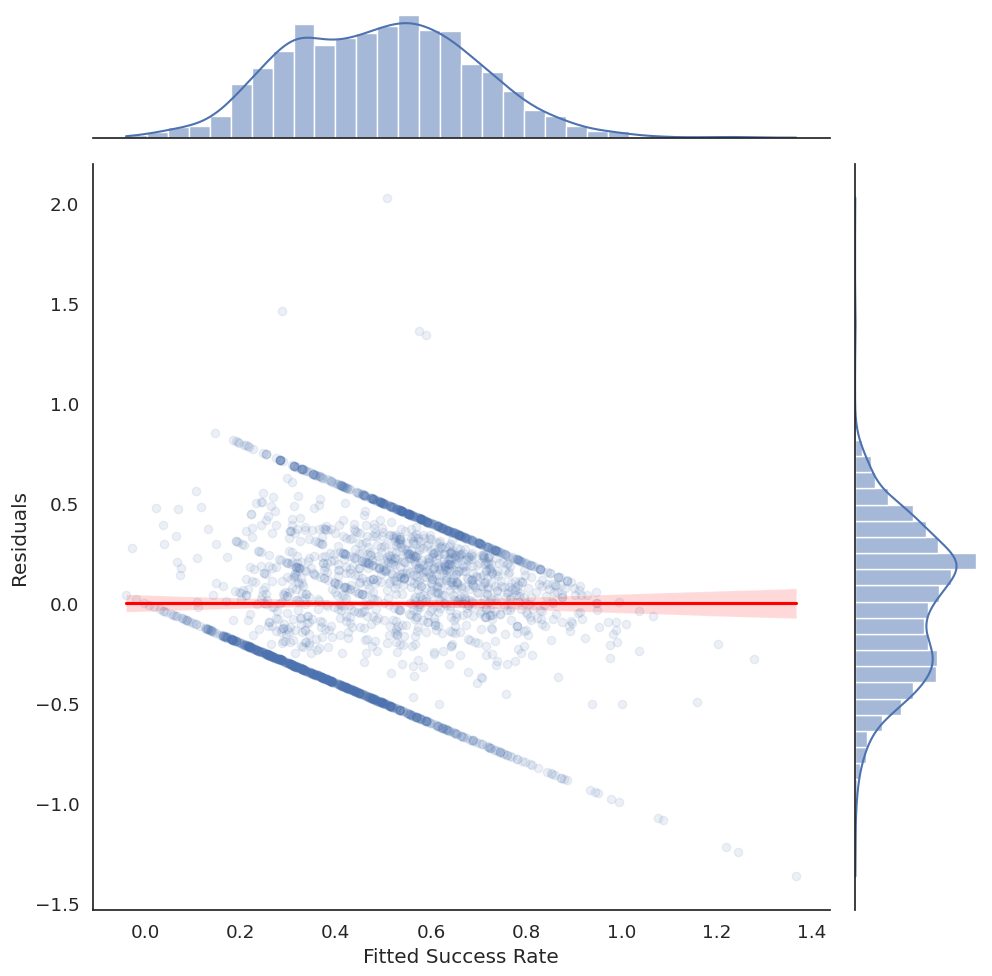

In [16]:
# --- Create regression-specific DataFrame ---
# Includes ONLY variables used in the model
df_reg = df_clean[
    [
        "Year",
        "route_codes",
        "mbr_hired_ratio",
        "group_size",
        "yearly_members",   # NEW crowding variable
        "MultiNational",
        "success_rate"
    ]
].copy()

# Drop rows with any missing values
df_reg.dropna(inplace=True)

# --- Heteroscedasticity check: residuals vs fitted values ---
X = df_reg[
    [
        "Year",
        "route_codes",
        "mbr_hired_ratio",
        "group_size",
        "yearly_members",
        "MultiNational"
    ]
]
X = sm.add_constant(X)
y = df_reg["success_rate"]

ols_model = sm.OLS(y, X).fit()

df_reg["fitted"] = ols_model.fittedvalues
df_reg["residuals"] = ols_model.resid

# Jointplot (workshop-style)
sns.jointplot(
    data=df_reg,
    x="fitted",
    y="residuals",
    kind="reg",
    scatter_kws=dict(alpha=0.1),
    line_kws=dict(color="red"),
    height=10
)

plt.xlabel("Fitted Success Rate")
plt.ylabel("Residuals")
plt.show()

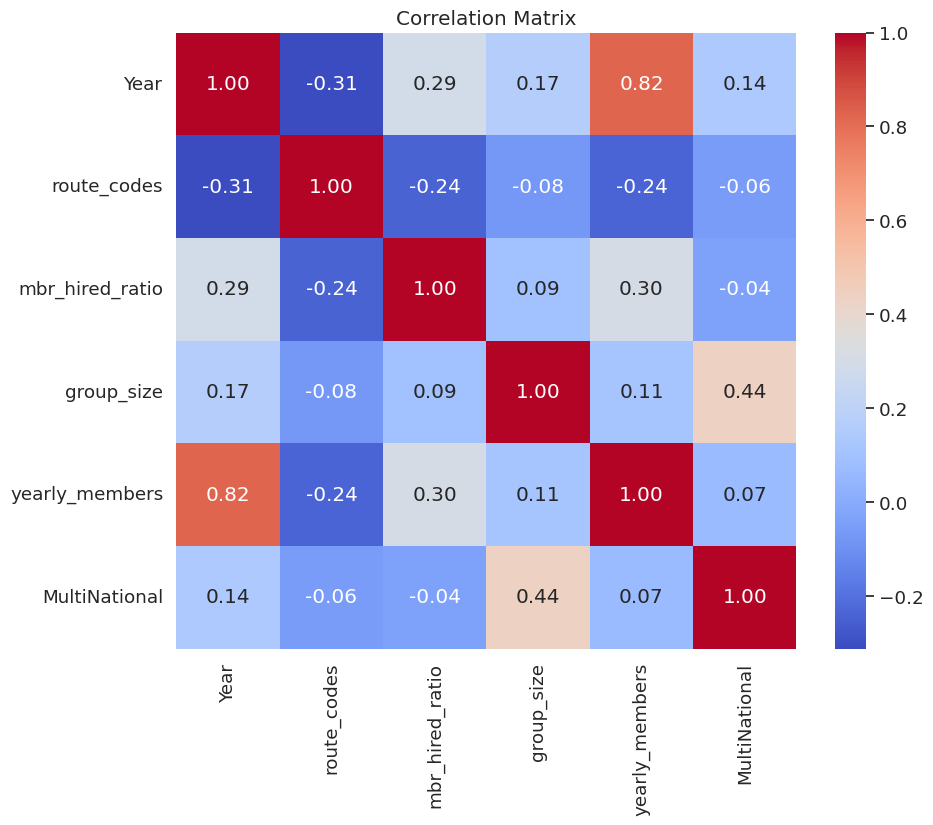

In [17]:
# --- Multicollinearity: Correlation Matrix ---
variables = df_reg[[
        "Year",
        "route_codes",
        "mbr_hired_ratio",
        "group_size",
        "yearly_members",
        "MultiNational"]]

sns.heatmap(
    variables.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

There is no general multicollinearity problem across the model.

The only serious issue is the overlap between Year and yearly_members.

This now becomes a modelling choice, not a data error: you need to decide whether Year is acting as a broad time trend control, or whether yearly_members is the mechanism you care about (crowding). Keeping both is possible, but you should expect inflated standard errors and should justify it carefully.

**We decided to keep both year and yearly_members for now. But we need to justify how they are different factors, they represent different things.**

In [18]:
# --- VIF (with your lecture function) ---
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def drop_column_using_vif_(df, list_var_not_to_remove=None, thresh=5):
    """
    Calculates VIF for each feature and repeatedly drops the column with the highest VIF
    until all VIFs are <= thresh.
    """
    df = df.copy()

    while True:
        df_with_const = add_constant(df)

        vif_df = pd.Series(
            [variance_inflation_factor(df_with_const.values, i)
             for i in range(df_with_const.shape[1])],
            name="VIF",
            index=df_with_const.columns
        ).to_frame()

        # drop const (never remove)
        vif_df = vif_df.drop("const")

        # optionally protect variables from being dropped (useful for dummy sets)
        if list_var_not_to_remove is not None:
            vif_df = vif_df.drop(list_var_not_to_remove, errors="ignore")

        print("Max VIF:", float(vif_df.VIF.max()))

        if vif_df.VIF.max() > thresh:
            index_to_drop = vif_df.VIF.idxmax()
            print(f"Dropping: {index_to_drop}")
            df = df.drop(columns=index_to_drop)
        else:
            break

    return df


# --- Build regression-ready df for VIF (update these names if yours differ) ---
cols_needed = [
    "success_rate",
    "Year",
    "yearly_members",     # your new crowding proxy
    "mbr_hired_ratio",
    "group_size",
    "MultiNational",
    "Season",
    "route_codes",
]

df_reg = df_clean[cols_needed].dropna().copy()

# One-hot encode categoricals (VIF needs numeric columns)
season_dummies = pd.get_dummies(df_reg["Season"], prefix="Season", drop_first=True).astype(int)
route_dummies  = pd.get_dummies(df_reg["route_codes"], prefix="route", drop_first=True).astype(int)

# Base numeric predictors
X_base = df_reg[["Year", "yearly_members", "mbr_hired_ratio", "group_size", "MultiNational"]].copy()

# Full predictor matrix for VIF
X_vif_full = pd.concat([X_base, season_dummies, route_dummies], axis=1)

# Protect dummy variables from being dropped one-by-one (keeps the factor structure intact)
protected = list(season_dummies.columns) + list(route_dummies.columns)

print("\n=== VIF selection (INCLUDING yearly_members) ===")
vif_selected_with_yearly = drop_column_using_vif_(X_vif_full, list_var_not_to_remove=protected, thresh=5)
print("\nColumns remaining after VIF selection (with yearly_members):")
print(vif_selected_with_yearly.columns)


# --- Run again WITHOUT yearly_members (so you can compare) ---
X_vif_noyearly = X_vif_full.drop(columns=["yearly_members"], errors="ignore")

print("\n=== VIF selection (EXCLUDING yearly_members) ===")
vif_selected_without_yearly = drop_column_using_vif_(X_vif_noyearly, list_var_not_to_remove=protected, thresh=5)
print("\nColumns remaining after VIF selection (without yearly_members):")
print(vif_selected_without_yearly.columns)



=== VIF selection (INCLUDING yearly_members) ===
Max VIF: 3.4294839005524085

Columns remaining after VIF selection (with yearly_members):
Index(['Year', 'yearly_members', 'mbr_hired_ratio', 'group_size',
       'MultiNational', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'route_2', 'route_3', 'route_4', 'route_5', 'route_6'],
      dtype='object')

=== VIF selection (EXCLUDING yearly_members) ===
Max VIF: 1.3320913431406451

Columns remaining after VIF selection (without yearly_members):
Index(['Year', 'mbr_hired_ratio', 'group_size', 'MultiNational',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'route_2', 'route_3',
       'route_4', 'route_5', 'route_6'],
      dtype='object')


Although yearly crowding and year are strongly correlated, Variance Inflation Factor diagnostics indicate no severe multicollinearity. We therefore retain both variables, allowing us to separately identify the effect of congestion and residual time trends.

In [19]:
#Step 4: OLS Regression

# --- Build regression-ready dataset ---
df_reg = df_clean[
    [
        "success_rate",
        "Year",
        "yearly_members",      # crowding (system-level)
        "Season",
        "route_codes",
        "PrimaryNationality",
        "mbr_hired_ratio",
        "group_size",
        "MultiNational"
    ]
].copy()

# Drop rows with missing values
df_reg.dropna(inplace=True)

from statsmodels.formula.api import ols

# --- Final OLS regression ---
model = ols(
    'success_rate ~ Year + yearly_members + mbr_hired_ratio + group_size + MultiNational '
    '+ C(Season) + C(route_codes) + C(PrimaryNationality)',
    data=df_reg
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           success_rate   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     9.048
Date:                Sun, 11 Jan 2026   Prob (F-statistic):          3.12e-105
Time:                        10:51:04   Log-Likelihood:                -734.23
No. Observations:                2181   AIC:                             1674.
Df Residuals:                    2078   BIC:                             2260.
Df Model:                         102                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

It turns out that 90 different nationalities are tested against success rate individually.

We want to test whether nationality as a whole have an impact on success. So we will create a joint F-test for nationality. An F-test checks whether a group of variables matters together, rather than asking if each one matters on its own.

In [20]:
# Identify all nationality-related coefficients
nationality_terms = [
    term for term in model.params.index
    if term.startswith("C(PrimaryNationality)")
]

# Build joint null hypothesis: all nationality coefficients = 0
hypothesis = " = ".join(nationality_terms) + " = 0"

# Perform joint F-test
f_test_nationality = model.f_test(hypothesis)

print(f_test_nationality)


<F test: F=1.4645482207525633, p=0.0035715463584655664, df_denom=2.08e+03, df_num=89>


**The result of the F test is:**

F = 1.46

p = 0.0036

df_num = 89 (number of primary nationalities)

df_denom ≈ 2080 (residual degrees of freedom)

A joint F-test rejects the null hypothesis that all nationality coefficients are jointly zero (p < 0.01), indicating that nationality as a group contributes explanatory power to summit success rates. However, the relatively small F-statistic of 1.46 suggests that nationality plays a secondary role compared to core factors such as season, route choice, and support intensity.

In [23]:
#save the output to files for download
with open("ols_regression_results.txt", "w") as f:
    f.write(model.summary().as_text())